# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
# Set experiment configs
test_name = "new_CatBoost_Fine_Tune"
random_state = 42
test_size = 0.2
device_type = "gpu" # or cpu
n_jobs = -1
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"


- Source to Consider

In [10]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	"LBV", 
	"TDE", 
	"Nova", 
	"M dwarf", 
	"CV",
	"SLSN",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [11]:
path_data = os.path.join(FEATURE_BALANCED_DATA, 'features_40.csv')

logtxt += f"\nBalanced Data Set\n"

# Data

In [12]:
columns_to_use = list(data_dtype_dict.keys())

In [13]:
data = pd.read_csv(
    path_data,
    engine='c', 
    # usecols=columns_to_use,
    # dtype=data_dtype_dict,
)

data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)

uids = data['uid'].values
classes = data['Class'].values

print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


Balanced Data: 282753
10 sources to consider: 282753


- Training and Test Data

In [14]:
# Step 0: Define GV group and label
gv_classes = ["Nova", "M dwarf", "CV", "LBV"]
unified_label = "GV"

# Step 1: Initialize list to collect subsampled data
gv_subsample_list = []

# Step 2: For each GV class, sample a subset of rows per uid
for cls in gv_classes:
    cls_data = data[data['Class'] == cls]
    # Group by uid and sample {frac}% of each uid's samples (at least 1)
    sampled_data = cls_data.groupby('uid').apply(
        lambda df: df.sample(frac=0.25, random_state=42) if len(df) > 1 else df
    ).reset_index(drop=True)

    # Replace label to unified GV label
    sampled_data = sampled_data.copy()
    sampled_data['Class'] = unified_label
    gv_subsample_list.append(sampled_data)

# Step 3: Concatenate subsampled GV data
gv_data = pd.concat(gv_subsample_list, ignore_index=True)

# Step 4: Keep other classes unchanged
non_gv_data = data[~data['Class'].isin(gv_classes)]

# Step 5: Merge into final data
data = pd.concat([non_gv_data, gv_data], ignore_index=True)

# Step 6: Redefine sources_to_consider
sources_to_consider = [
    "AGN", 
    "Ia", 
    "II", 
    "Ibc", 
    "TDE", 
    "SLSN", 
    unified_label,
]
logtxt += f"\nSources to consider (with GV sampled): {sources_to_consider}\n"

# Step 7: Filter data again
indx_type_to_consider = np.where(
    np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)
print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]
uids = data['uid'].values
logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n\n"

# Step 8: Train/test split & encoding
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
y = data['Class']
X.fillna(-99, inplace=True)


7 sources to consider: 201000


In [15]:
# - Split features/target
# X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
# y = data['Class']
# X.fillna(-99, inplace=True)

# - Split into train/test using GroupShuffleSplit by uid
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=uids))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# - Label encode class for ML
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)

# Tets\\sts
classifier_type = 'normal_class_classifier'
model_param_config = model_config[classifier_type][device_type]

from catboost import Pool
train_pool = Pool(X_train, label=y_train)
eval_pool = Pool(X_test, label=y_test)

Balanced: Class mapping: ['AGN' 'GV' 'II' 'Ia' 'Ibc' 'SLSN' 'TDE']


TBB Warning: The number of workers is currently limited to 9. The request for 95 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



In [16]:
print(len(X), len(y), len(uids))

201000 201000 201000


In [17]:
del data

# Fine Tuning

In [18]:
import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
import optuna
from catboost import CatBoostClassifier
import gc # objective 함수 상단에 추가

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 800, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 5),
        'border_count': trial.suggest_int('border_count', 128, 254),
        'random_state': random_state,
        'verbose': 0,
        'thread_count': n_jobs,
        'task_type': device_type.upper(),
    }
    # print("Optimization Start with parameter ranges:")
    # print(params)
    #
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=eval_pool, early_stopping_rounds=30)
    y_pred = model.predict(X_test)

    del model
    gc.collect()

    return f1_score(y_test, y_pred, average='macro')

In [19]:
number_of_trials = 50

best_parameter_filename = f"{path_save}/best_params_n{number_of_trials}.yaml"

if not os.path.exists(best_parameter_filename):

    t0 = time.time()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=number_of_trials)
    delt = time.time() - t0
    print(f"It takes {delt/60:.1f} min")
    print(f"Best Value = {study.best_value}, Best Parameters = {study.best_params}")
    print("Best trial:")
    trial = study.best_trial

    print("Value: ", trial.value)
    print("Params: ")
    for key, value in trial.params.items():
        print(f"{key}: {value}")

    from optuna.visualization import plot_optimization_history, plot_param_importances
    import hiplot as hip

    plot_optimization_history(study)
    data = [dict(trial.params, value=trial.value) for trial in study.trials]
    hip.Experiment.from_iterable(data).display()
    best_params = trial.params

else:
    with open(best_parameter_filename, 'r', encoding='utf-8') as file:
        best_params = yaml.safe_load(file)


best_params['random_state'] = 42
best_params['thread_count'] = n_jobs
if device_type.upper() == 'GPU':
    best_params['task_type'] = device_type.upper()
    
#

import yaml
with open(best_parameter_filename, "w") as f:
    yaml.dump(best_params, f, default_flow_style=False)


[I 2025-06-04 10:11:05,273] A new study created in memory with name: no-name-8c3b8c88-6862-4630-b336-842a7592dd2a
[I 2025-06-04 10:11:57,194] Trial 0 finished with value: 0.7995365909104268 and parameters: {'iterations': 882, 'learning_rate': 0.05321510998100334, 'depth': 6, 'l2_leaf_reg': 5, 'border_count': 230}. Best is trial 0 with value: 0.7995365909104268.
[I 2025-06-04 10:12:34,599] Trial 1 finished with value: 0.8096477554192582 and parameters: {'iterations': 1702, 'learning_rate': 0.08760255974307037, 'depth': 5, 'l2_leaf_reg': 4, 'border_count': 218}. Best is trial 1 with value: 0.8096477554192582.
[I 2025-06-04 10:14:17,883] Trial 2 finished with value: 0.8071845075446291 and parameters: {'iterations': 1608, 'learning_rate': 0.023545656701088238, 'depth': 6, 'l2_leaf_reg': 3, 'border_count': 204}. Best is trial 1 with value: 0.8096477554192582.
[I 2025-06-04 10:16:49,797] Trial 3 finished with value: 0.80300862141464 and parameters: {'iterations': 1666, 'learning_rate': 0.065

It takes 110.5 min
Best Value = 0.8160105144975819, Best Parameters = {'iterations': 1988, 'learning_rate': 0.05892133369051283, 'depth': 10, 'l2_leaf_reg': 5, 'border_count': 183}
Best trial:
Value:  0.8160105144975819
Params: 
iterations: 1988
learning_rate: 0.05892133369051283
depth: 10
l2_leaf_reg: 5
border_count: 183


<IPython.core.display.Javascript object>

# Take Best Parameter 

In [20]:
best_params

{'iterations': 1988,
 'learning_rate': 0.05892133369051283,
 'depth': 10,
 'l2_leaf_reg': 5,
 'border_count': 183,
 'random_state': 42,
 'thread_count': -1,
 'task_type': 'GPU'}

In [21]:
# best_model = CatBoostClassifier(**best_params)
# best_model.fit(
#     train_pool, eval_set=eval_pool, early_stopping_rounds=30
#     )
# y_pred = best_model.predict(X_test)
# best_model.save_model(f"{path_save}/best_lightgbm_model.txt")

# Results - 5-fold CV

Start Training
0:	learn: 1.8024078	test: 1.8278819	best: 1.8278819 (0)	total: 578ms	remaining: 19m 9s
1:	learn: 1.6909470	test: 1.7329423	best: 1.7329423 (1)	total: 1.07s	remaining: 17m 45s
2:	learn: 1.5920024	test: 1.6513664	best: 1.6513664 (2)	total: 1.6s	remaining: 17m 42s
3:	learn: 1.5119254	test: 1.5846591	best: 1.5846591 (3)	total: 2.12s	remaining: 17m 30s
4:	learn: 1.4404233	test: 1.5215468	best: 1.5215468 (4)	total: 2.63s	remaining: 17m 22s
5:	learn: 1.3791971	test: 1.4713702	best: 1.4713702 (5)	total: 3.14s	remaining: 17m 16s
6:	learn: 1.3231069	test: 1.4259702	best: 1.4259702 (6)	total: 3.64s	remaining: 17m 10s
7:	learn: 1.2729037	test: 1.3844909	best: 1.3844909 (7)	total: 4.16s	remaining: 17m 10s
8:	learn: 1.2270528	test: 1.3488011	best: 1.3488011 (8)	total: 4.68s	remaining: 17m 8s
9:	learn: 1.1828743	test: 1.3115637	best: 1.3115637 (9)	total: 5.21s	remaining: 17m 9s
10:	learn: 1.1460816	test: 1.2810235	best: 1.2810235 (10)	total: 5.71s	remaining: 17m 5s
11:	learn: 1.1087764

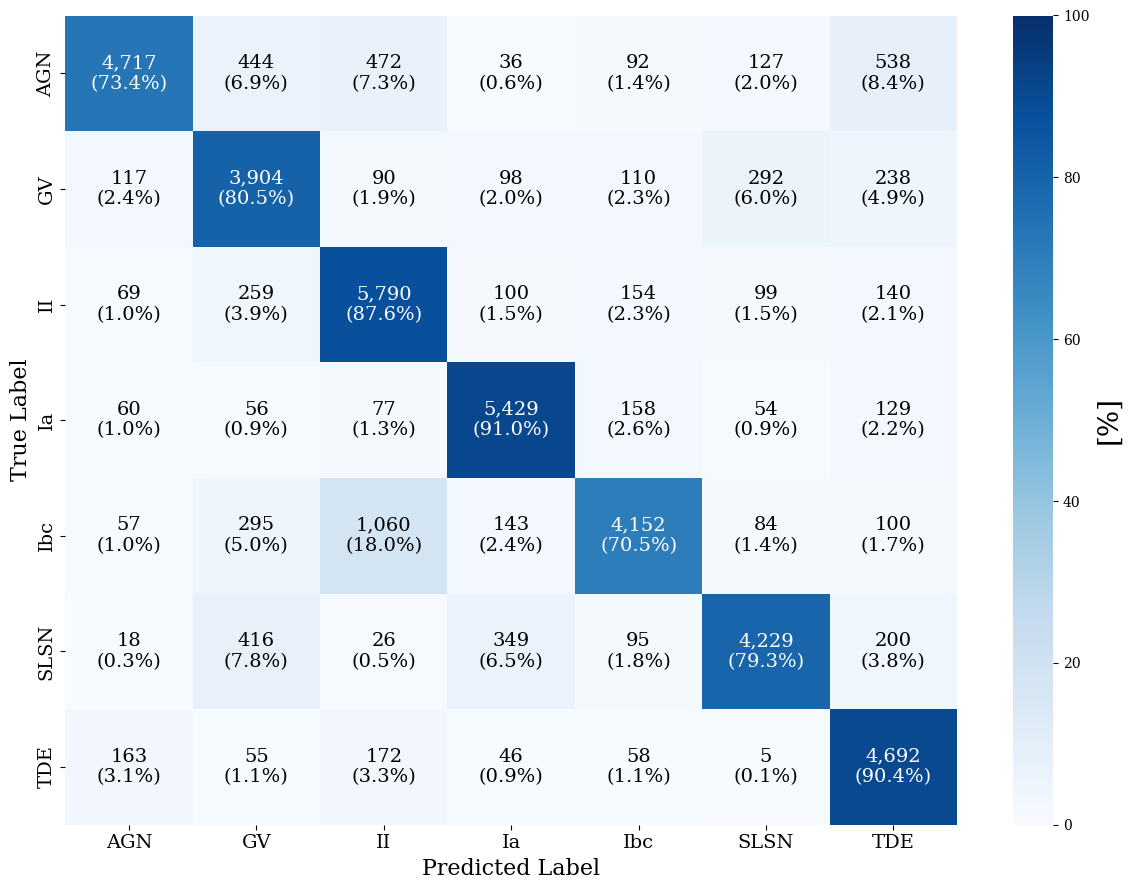

In [22]:

from lightgbm import LGBMClassifier  # 예시로 LGBM 사용
import joblib  # for XGBoost and LightGBM
from sklearn.metrics import classification_report
import pandas as pd
import joblib
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report

# 저장 경로 생성
os.makedirs(path_save, exist_ok=True)

df_cm_filename = os.path.join(path_save, f'confusion_matrix.csv')

# feature_to_use = rubin_added_feature_dict[filte]
# X_sub = X[feature_to_use]
# X_train_sub = X_train[feature_to_use]
# X_test_sub = X_test[feature_to_use]

if not os.path.exists(df_cm_filename):
    
    #
    print(f"Start Training")
    best_model = CatBoostClassifier(**best_params)
    best_model.fit(
        train_pool, eval_set=eval_pool, early_stopping_rounds=30
        )
    y_pred = best_model.predict(X_test)
    # best_model.save_model(f"{path_save}/best_lightgbm_model.txt")
    #
    
    # # ---------------------
    # # CatBoost 저장
    # # ---------------------
    # cat_model.save_model(os.path.join(path_save, "best_catboost_model.txt"))
    
    # # ---------------------
    # # XGBoost 저장
    # # ---------------------
    # xgb_model.save_model(os.path.join(path_save, "best_xgboost_model.json"))  # .json preferred over .txt
    
    # # ---------------------
    # # LightGBM 저장
    # # ---------------------
    joblib.dump(best_model, os.path.join(path_save, f"catboost_7DT.pkl"))
    #

    print(f"Get Classification Report")
    report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    
    # 2. accuracy는 scalar → 딕셔너리로 따로 저장
    acc_value = report_dict.pop("accuracy")
    
    # 3. DataFrame으로 변환
    report_df = pd.DataFrame(report_dict).T  # class별 성능 포함
    
    # 4. accuracy row 추가 (f1-score 칸만 채움)
    report_df.loc["accuracy"] = [None, None, acc_value, report_df["support"].sum()]
    report_df.to_csv(os.path.join(path_save, f"classification_report.csv"))

    print(f"Get Confusion Matrix")
    plot_confusion_matrix(y_test, y_pred, class_names)
    plt.savefig(os.path.join(path_save, f'confusion_matrix.png'))
    # plt.close()
    
    cm = confusion_matrix(y_test, y_pred)
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    df_cm.to_csv(df_cm_filename)
else:
    print(df_cm_filename, "exists")



In [33]:
# 설정
class_labels = label_encoder.classes_
gkf = GroupKFold(n_splits=5)

cv_macro_f1_scores = []
cv_per_class_f1_scores = []


print(f"Calculate 5-Fold Cross-Validation Values")

all_pool = Pool(X, label=y)

# Perform Grouped K-Fold Cross-Validation
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_encoded, groups=uids)):

    macro_f1_df_filename = os.path.join(path_save, f"cv_macro_f1_scores_{fold}.csv")
    per_class_f1_df_filename = os.path.join(path_save, f"cv_per_class_f1_scores_{fold}.csv")

    if (not os.path.exists(macro_f1_df_filename)) & ((not os.path.exists(per_class_f1_df_filename))):
        # X, y_encoded 부분을 Pool 객체 슬라이싱으로 수정
        train_pool = all_pool.slice(train_idx) # Pool 객체를 인덱싱하여 train_pool 생성
        val_pool = all_pool.slice(val_idx)     # Pool 객체를 인덱싱하여 val_pool 생성

        model_cv = CatBoostClassifier(**best_params)
        model_cv.fit(
            train_pool, # Pool 객체를 직접 전달
            eval_set=val_pool, # eval_set에도 Pool 객체를 직접 전달
            # verbose=False # 필요에 따라 주석 해제
            early_stopping_rounds=30,
        )

        # X_val_cv 대신 val_pool을 사용하여 예측
        y_pred = model_cv.predict(val_pool)

        # === 1. Macro F1 저장 ===
        # y_val_cv 대신 val_pool.get_label()을 사용하여 실제 레이블 가져오기
        macro_f1 = f1_score(val_pool.get_label(), y_pred, average='macro')
        cv_macro_f1_scores.append({'fold': fold, 'f1_macro': macro_f1})

        # === 2. Per-class F1 저장 ===
        # y_val_cv 대신 val_pool.get_label()을 사용하여 실제 레이블 가져오기
        report = classification_report(val_pool.get_label(), y_pred, output_dict=True, zero_division=0)
        per_class_f1 = {str(label): report[str(label)]['f1-score'] for i, label in enumerate(class_labels)} # Ensure keys are strings for report
        per_class_f1['fold'] = fold
        cv_per_class_f1_scores.append(per_class_f1)

        # === 3. 모델 저장 ===
        model_path = os.path.join(path_save, f"model_fold{fold}.pkl")
        joblib.dump(model_cv, model_path)

        # === 4. 리포트 출력 ===
        print(f"[Fold {fold}] f1_macro = {macro_f1:.3f}")

        # === 5. 최종 결과 저장 ===
        # 루프 바깥에서 한 번만 저장하는 것이 효율적일 수 있으나,
        # 각 폴드마다 저장하려면 현재 위치도 괜찮습니다.
        macro_f1_df = pd.DataFrame(cv_macro_f1_scores)
        per_class_f1_df = pd.DataFrame(cv_per_class_f1_scores)

        macro_f1_df.to_csv(macro_f1_df_filename, index=False)
        per_class_f1_df.to_csv(per_class_f1_df_filename, index=False)
    else:
        print(macro_f1_df_filename, "exists")
        print(per_class_f1_df_filename, "exists")

Calculate 5-Fold Cross-Validation Values
/home/gpaek/SED-Classifier/notebook/../model/new_CatBoost_Fine_Tune/cv_macro_f1_scores_0.csv exists
/home/gpaek/SED-Classifier/notebook/../model/new_CatBoost_Fine_Tune/cv_per_class_f1_scores_0.csv exists
0:	learn: 1.8017347	test: 1.8368651	best: 1.8368651 (0)	total: 568ms	remaining: 18m 49s
1:	learn: 1.6849889	test: 1.7431726	best: 1.7431726 (1)	total: 1.08s	remaining: 17m 55s
2:	learn: 1.5918455	test: 1.6663303	best: 1.6663303 (2)	total: 1.59s	remaining: 17m 33s
3:	learn: 1.5078332	test: 1.6022999	best: 1.6022999 (3)	total: 2.09s	remaining: 17m 17s
4:	learn: 1.4335394	test: 1.5413899	best: 1.5413899 (4)	total: 2.6s	remaining: 17m 10s
5:	learn: 1.3695900	test: 1.4854939	best: 1.4854939 (5)	total: 3.12s	remaining: 17m 10s
6:	learn: 1.3095226	test: 1.4375017	best: 1.4375017 (6)	total: 3.65s	remaining: 17m 11s
7:	learn: 1.2577910	test: 1.3985450	best: 1.3985450 (7)	total: 4.16s	remaining: 17m 9s
8:	learn: 1.2101823	test: 1.3594337	best: 1.3594337 (

In [34]:
macro_f1_df

,fold,f1_macro
0,1,0.780266
1,2,0.833318
2,3,0.791059
3,4,0.803047
